In [1]:
# ============================================================
# 1. Physics Defined & Imports
# ============================================================

"""
Physics-Informed Neural Network: Euler Beam Problem

Governing Equation:       d⁴u/dx⁴ + 1 = 0,  x ∈ [0,1]

BCs:                      u(0)=0, 
                          u'(0)=0, 
                          
                          u''(1)=0,
                          u'''(1)=0

Exact Solution:           u(x) = -(1/24)x⁴ + (1/6)x³ - (1/4)x²
"""

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# ============================================================
# 2. SETUP
# ============================================================
dde.config.set_default_float("float64")
print(f"Backend: {dde.backend.backend_name}")

# Exact solution for validation
def exact_solution(x):
    return -(1/24) * x**4 + (1/6) * x**3 - (1/4) * x**2

Set the default float type to float64
Backend: pytorch


In [3]:
# ============================================================
# 3. DEFINE PROBLEM
# ============================================================

# Domain geometry
geom = dde.geometry.Interval(0, 1)



# PDE: d⁴u/dx⁴ + 1 = 0
# i, j = differentiation indexes → (0,0) means d⁴u/dx⁴ + 1 = 0
def pde(x, y):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    dy_xxxx = dde.grad.hessian(dy_xx, x, i=0, j=0)
    return dy_xxxx + 1



# Left boundary conditions at x=0
def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)

# u(0) = 0 (Dirichlet)
bc_u_0 = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_left)

# u'(0) = 0 (Neumann - first derivative)
bc_du_0 = dde.icbc.NeumannBC(geom, lambda x: 0, boundary_left)



# Right boundary conditions at x=1
def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)



# u''(1) = 0 (OperatorBC - second derivative)
bc_obc1 = dde.icbc.OperatorBC(
    geom,
    lambda x, y, _: dde.grad.hessian(y, x, i=0, j=0),
    boundary_right
)



# u'''(1) = 0 (OperatorBC - third derivative)
def boundary_third_derivative(x, y, _):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    dy_xxx = dde.grad.jacobian(dy_xx, x, i=0, j=0)
    return dy_xxx

bc_obc2 = dde.icbc.OperatorBC(geom, boundary_third_derivative, boundary_right)

In [ ]:
# ============================================================
# 4. GENERATE DATA
# ============================================================
# # 1. Load experimental data (If actual Experimental or FEA Data is Available)
    # pip install pandas
    # pip install numpy
    # pip install scikit-learn

    # import pandas as pd
    # import numpy as np
    # from sklearn.model_selection import train_test_split

    # # Load your experimental/FEA data
    # df = pd.read_excel("experiment_data.xlsx")

    # # Extract full dataset
    # X = df['x'].values.reshape(-1, 1)
    # Y = df['y'].values.reshape(-1, 1)

    # # RANDOM 85% Train — 15% Test
    # X_train, X_test, Y_train, Y_test = train_test_split(
    #     X, Y, test_size=0.15, shuffle=True, random_state=42
    # )

    # # Observation data for PINN
    # observe_x = X_train
    # observe_y = Y_train



# Create training data (35 measurements + 3200 physics points)
observe_x = np.linspace(0, 1, 35).reshape(-1, 1)
observe_y = exact_solution(observe_x)
noise = 0.05 * observe_y.std() * np.random.randn(35, 1)   # 5% noise
observe_y = observe_y + noise
observe = dde.icbc.PointSetBC(observe_x, observe_y, component=0)



# Combine all data
data = dde.data.PDE(
    geom,
    pde,
    [bc_u_0, bc_du_0, bc_obc1, bc_obc2, observe],
    num_domain=3000,      # Physics collocation points
    num_boundary=200,     # Boundary points
    num_test=500        # Test points for evaluation
)

In [5]:
# ============================================================
# 5. BUILD NEURAL NETWORK
# ============================================================

# Architecture: 1 input → 3 hidden layers → 1 output
net = dde.nn.FNN([1, 128, 64, 32, 1], "tanh", "Glorot uniform")

In [6]:
# ============================================================
# 6. CREATE MODEL
# ============================================================

model = dde.Model(data, net)

In [7]:
# ============================================================
# 7. SET LOSS WEIGHTS (λ parameters)
# ============================================================

"""
CRITICAL: DeepXDE loss weight configuration

Loss components:
  - losses[0]: PDE residual loss (L_PDE)
  - losses[1]: Left BC loss (L_BC_left)
  - losses[2]: Right BC loss (L_BC_right)
  - losses[3]: Data loss (L_data)

Total Loss = λ_PDE*L_PDE + λ_BC_left*L_BC_left + λ_BC_right*L_BC_right + λ_data*L_data
"""

# Define loss weights (tune these for your problem)
loss_weights = [
    1.0,    # λ_PDE: Physics equation weight
    20.0,   # λ_BC: u(0)=0
    20.0,   # λ_BC: u'(0)=0
    20.0,   # λ_BC: u''(1)=0
    20.0,   # λ_BC: u'''(1)=0
    500.0   # λ_data: Data fitting weight
]

print("\n" + "="*60)
print("📊 LOSS WEIGHT CONFIGURATION")
print("="*60)
print(f"λ_PDE (Physics):        {loss_weights[0]}")
print(f"λ_BC (u(0)=0):          {loss_weights[1]}")
print(f"λ_BC (u'(0)=0):         {loss_weights[2]}")
print(f"λ_BC (u''(1)=0):        {loss_weights[3]}")
print(f"λ_BC (u'''(1)=0):       {loss_weights[4]}")
print(f"λ_data (Measurements):  {loss_weights[5]}")
print("="*60)


📊 LOSS WEIGHT CONFIGURATION
λ_PDE (Physics):        1.0
λ_BC (u(0)=0):          20.0
λ_BC (u'(0)=0):         20.0
λ_BC (u''(1)=0):        20.0
λ_BC (u'''(1)=0):       20.0
λ_data (Measurements):  500.0


In [8]:
# ============================================================
# 8. TRAIN MODEL (Two-Stage Optimization)
# ============================================================
print("\nStage 1: Adam Optimizer")
model.compile(
    "adam",
    lr=0.001,
    loss_weights=loss_weights,
    decay=("inverse time", 10000, 0.1)   # LR will decrease slowly → convergence better
)
losshistory, train_state = model.train(iterations=5000, display_every=1000)

print("\nStage 2: L-BFGS Optimizer (Fine-tuning)")
model.compile("L-BFGS", loss_weights=loss_weights)  # weights are necessary to pass again
losshistory, train_state = model.train(display_every=200)


Stage 1: Adam Optimizer
Compiling model...
'compile' took 2.221892 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.00e+00, 0.00e+00, 7.66e-01, 1.15e-02, 1.21e-02, 1.26e+00]    [1.00e+00, 0.00e+00, 7.66e-01, 1.15e-02, 1.21e-02, 1.26e+00]    []  
1000      [7.52e-03, 2.34e-06, 3.08e-05, 4.79e-06, 5.76e-05, 4.19e-03]    [5.82e-03, 2.34e-06, 3.08e-05, 4.79e-06, 5.76e-05, 4.19e-03]    []  
2000      [2.93e-04, 8.04e-08, 2.46e-05, 8.41e-08, 7.18e-07, 4.60e-03]    [2.42e-04, 8.04e-08, 2.46e-05, 8.41e-08, 7.18e-07, 4.60e-03]    []  
3000      [3.10e-04, 3.05e-06, 8.11e-09, 8.14e-06, 2.88e-06, 4.05e-03]    [2.61e-04, 3.05e-06, 8.11e-09, 8.14e-06, 2.88e-06, 4.05e-03]    []  
4000      [3.32e-04, 3.07e-06, 3.03e-14, 8.48e-06, 2.53e-06, 4.05e-03]    [2.85e-04, 3.07e-06, 3.03e-14, 8.48e-06, 2.53e-06, 4.05e-03]    []  
5000      [4.45e-04, 2.19e-06, 7.71e-07, 2.34

In [9]:
# ============================================================
# 9. EVALUATE RESULTS
# ============================================================

# # 1. Load experimental test data (If actual Experimental or FEA Data is Available)
    # x_test = X_test
    # y_test = Y_test

test_points = 15
x_test = np.linspace(0, 1, test_points).reshape(-1, 1)
y_pred = model.predict(x_test)
y_exact = exact_solution(x_test)
noise = 0.05 * y_exact.std() * np.random.randn(15, 1)   # 5% noise
y_test = y_exact + noise

absolute_error = np.abs(y_test - y_pred)
relative_error = absolute_error / (np.abs(y_test) + 1e-10)
l2_error = np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)



# Boundary checks
x_0 = np.array([[0.0]])
x_1 = np.array([[1.0]])

u_at_0 = model.predict(x_0)[0, 0]
du_dx_at_0 = model.predict(x_0, operator=lambda x, y: dde.grad.jacobian(y, x, i=0, j=0))[0, 0]
d2u_dx2_at_1 = model.predict(x_1, operator=lambda x, y: dde.grad.hessian(y, x, i=0, j=0))[0, 0]

# Third derivative at x=1
d3u_dx3_at_1 = model.predict(x_1, operator=lambda x, y: dde.grad.jacobian(
    dde.grad.hessian(y, x, i=0, j=0), x, i=0, j=0))[0, 0]

print("\n" + "="*60)
print("📊 PERFORMANCE METRICS")
print("="*60)
print(f"L2 Relative Error:      {l2_error:.6f}")
print(f"Max Absolute Error:     {np.max(absolute_error):.6f}")
print(f"Mean Absolute Error:    {np.mean(absolute_error):.6f}")

print("\n📍 BOUNDARY CONDITION CHECK")
print("-"*60)
print(f"u(0) = {u_at_0:.6f}  (Target: 0.0)")
print(f"u'(0) = {du_dx_at_0:.6f}  (Target: 0.0)")
print(f"u''(1) = {d2u_dx2_at_1:.6f}  (Target: 0.0)")
print(f"u'''(1) = {d3u_dx3_at_1:.6f}  (Target: 0.0)")
print("="*60)


📊 PERFORMANCE METRICS
L2 Relative Error:      0.033879
Max Absolute Error:     0.006417
Mean Absolute Error:    0.001595

📍 BOUNDARY CONDITION CHECK
------------------------------------------------------------
u(0) = 0.000392  (Target: 0.0)
u'(0) = -0.000053  (Target: 0.0)
u''(1) = -0.000806  (Target: 0.0)
u'''(1) = 0.000368  (Target: 0.0)


In [10]:
# ==================================
# 10. EXTRACT TRUE INDIVIDUAL LOSSES
# ==================================
# DeepXDE already computes the exact losses used during training
final_train_losses = model.losshistory.loss_train[-1]   # [L_PDE, L_BC1, L_BC2, L_BC3, L_BC4, L_data]

L_pde, L_bc1, L_bc2, L_bc3, L_bc4, L_data = final_train_losses



print("\n" + "="*60)
print("📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)")
print("="*60)
print(f"L_PDE         : {L_pde:.6e}")
print(f"L_BC_u(0)     : {L_bc1:.6e}")
print(f"L_BC_u'(0)    : {L_bc2:.6e}")
print(f"L_BC_u''(1)   : {L_bc3:.6e}")
print(f"L_BC_u'''(1)  : {L_bc4:.6e}")
print(f"L_data        : {L_data:.6e}")



print("\n📉 WEIGHTED CONTRIBUTIONS")
print("="*60)
weighted = [w * l for w, l in zip(loss_weights, final_train_losses)]
print(f"λ_PDE     × L_PDE         : {weighted[0]:.6e}")
print(f"λ_BC_u(0) × L_BC_u(0)     : {weighted[1]:.6e}")
print(f"λ_BC_u'(0) × L_BC_u'(0)   : {weighted[2]:.6e}")
print(f"λ_BC_u''(1) × L_BC_u''(1) : {weighted[3]:.6e}")
print(f"λ_BC_u'''(1) × L_BC_u'''(1): {weighted[4]:.6e}")
print(f"λ_data    × L_data        : {weighted[5]:.6e}")
print(f"\nTotal Weighted Loss       : {sum(weighted):.6e}")
print("="*60)


📉 FINAL TRAINING LOSSES (Unweighted - REAL values used by DeepXDE)
L_PDE         : 8.718489e-06
L_BC_u(0)     : 3.067047e-06
L_BC_u'(0)    : 5.661431e-08
L_BC_u''(1)   : 1.298522e-05
L_BC_u'''(1)  : 2.702083e-06
L_data        : 4.047986e-03

📉 WEIGHTED CONTRIBUTIONS
λ_PDE     × L_PDE         : 8.718489e-06
λ_BC_u(0) × L_BC_u(0)     : 6.134095e-05
λ_BC_u'(0) × L_BC_u'(0)   : 1.132286e-06
λ_BC_u''(1) × L_BC_u''(1) : 2.597044e-04
λ_BC_u'''(1) × L_BC_u'''(1): 5.404165e-05
λ_data    × L_data        : 2.023993e+00

Total Weighted Loss       : 2.024378e+00



💾 Results saved to 'pinn_poisson_results.png'


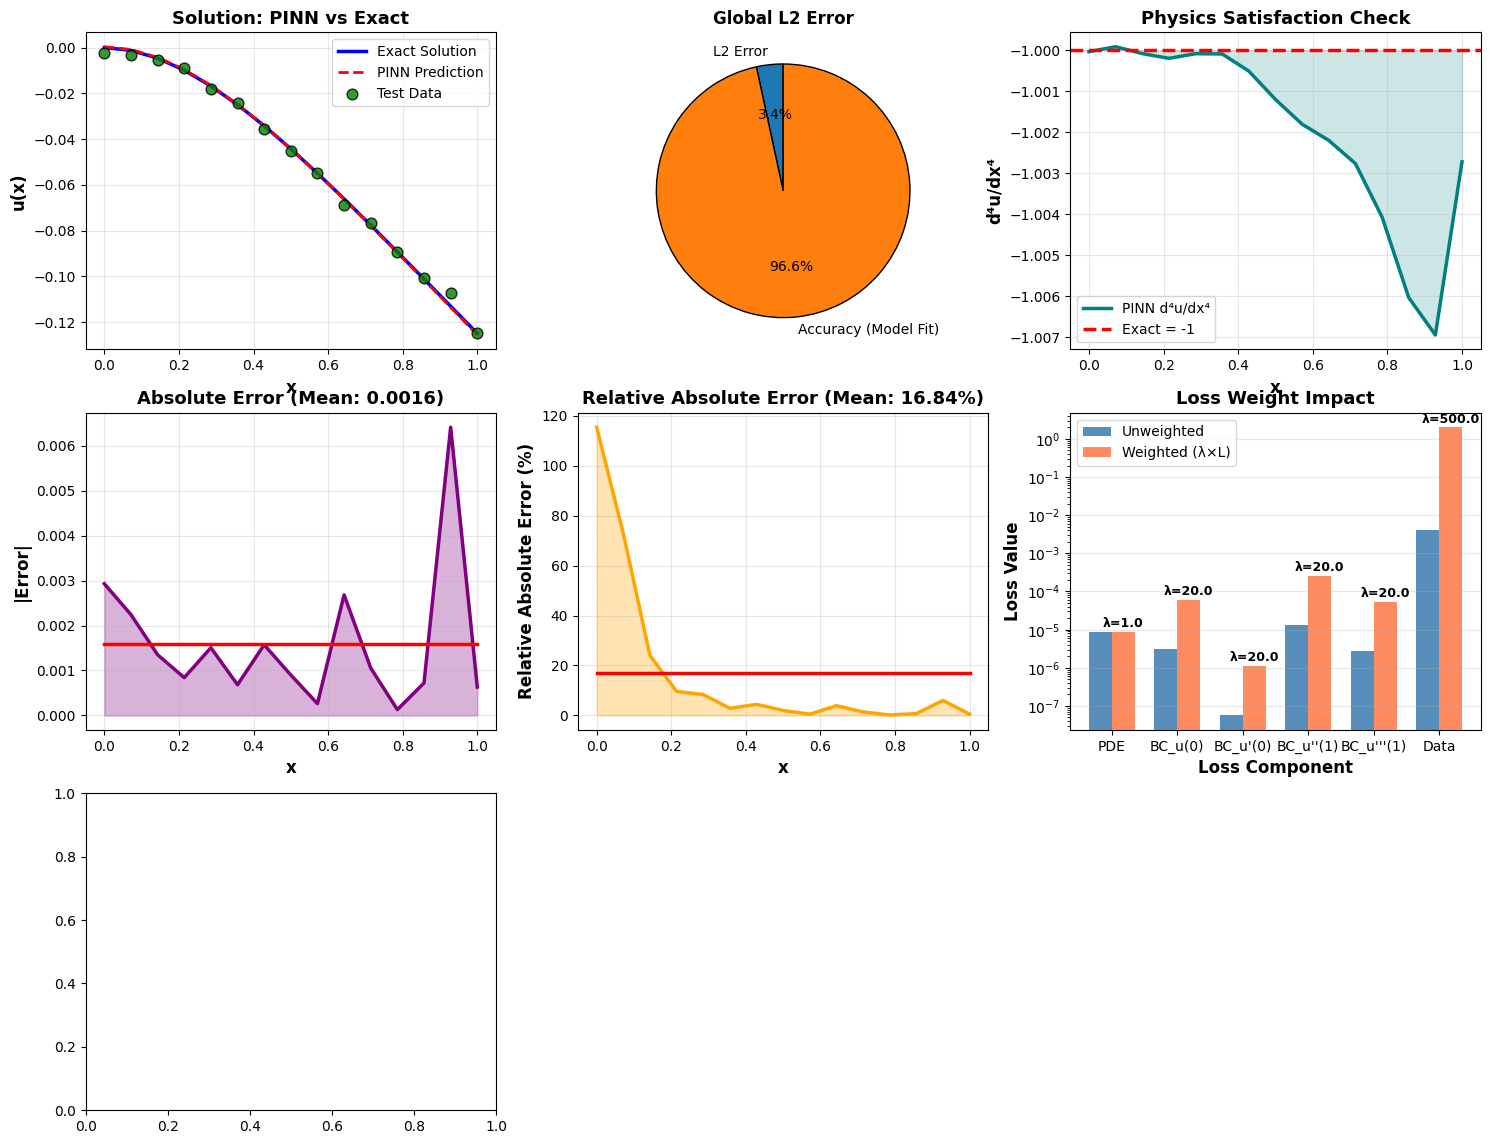

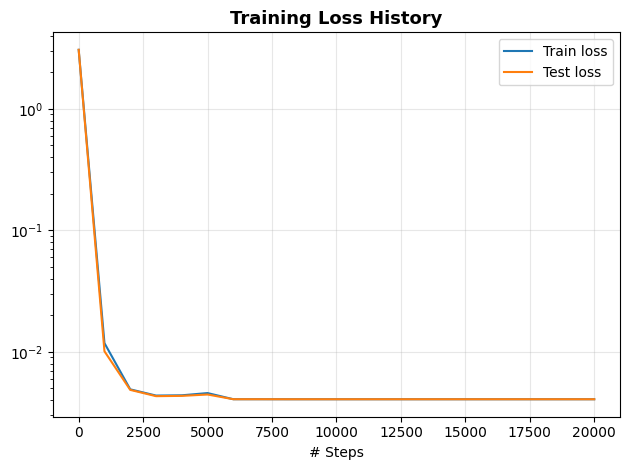

In [11]:
# ============================================================
# 11. VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(18, 14))

# Plot 1: Solution Comparison
ax1 = plt.subplot(3, 3, 1)
plt.plot(x_test, y_exact, 'b-', linewidth=2.5, label='Exact Solution')
plt.plot(x_test, y_pred, 'r--', linewidth=2, label='PINN Prediction')
plt.scatter(x_test, y_test, c='green', s=60, 
            label='Test Data', zorder=5, alpha=0.8, edgecolors='black')
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('u(x)', fontsize=12, fontweight='bold')
plt.title('Solution: PINN vs Exact', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)





# -----------------------------------------------
# Plot 2: Global L2 Error Pie Chart
# -----------------------------------------------
ax2 = plt.subplot(3, 3, 2)

# Compute L2 error (%)
l2_error_pct = 100 * np.linalg.norm(y_test - y_pred) / np.linalg.norm(y_test)

# Pie chart values
sizes = [l2_error_pct, 100 - l2_error_pct]
labels = [f'L2 Error', 'Accuracy (Model Fit)']

# Draw pie chart inside subplot
ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
)

ax2.set_title('Global L2 Error', fontsize=12, fontweight='bold')

# VERY IMPORTANT so pie fits well inside subplot
ax2.set_aspect('equal')





# Plot 3: Physics Check
ax3 = plt.subplot(3, 3, 3)

# Compute d⁴u/dx⁴ using the same method as in PDE definition
def compute_d4u_dx4(x, y):
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    dy_xxxx = dde.grad.hessian(dy_xx, x, i=0, j=0)
    return dy_xxxx

d4u_dx4 = model.predict(x_test, operator=compute_d4u_dx4)

plt.plot(x_test, d4u_dx4, 'teal', linewidth=2.5, label='PINN d⁴u/dx⁴')
plt.axhline(y=-1, color='red', linestyle='--', linewidth=2.5, label='Exact = -1')
plt.fill_between(x_test.flatten(), -1, d4u_dx4.flatten(), alpha=0.2, color='teal')
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('d⁴u/dx⁴', fontsize=12, fontweight='bold')
plt.title('Physics Satisfaction Check', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)





# Plot 4: Absolute Error
ax4 = plt.subplot(3, 3, 4)

# Absolute error curve
plt.plot(x_test, absolute_error, color='purple', linewidth=2.5)

# Mean absolute error line (constant horizontal line)
mean_abs_err = np.mean(absolute_error)
plt.plot(x_test, np.full_like(x_test, mean_abs_err), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, absolute_error.flatten(), alpha=0.3, color='purple')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('|Error|', fontsize=12, fontweight='bold')
plt.title(f'Absolute Error (Mean: {np.mean(absolute_error):.4f})',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 5: Relative Absolute Error
ax5 = plt.subplot(3, 3, 5)

# Relative absolute error curve (%)
plt.plot(x_test, relative_error * 100, color='orange', linewidth=2.5)

# Mean relative error line (horizontal)
mean_rel_err_pct = np.mean(relative_error) * 100
plt.plot(x_test, np.full_like(x_test, mean_rel_err_pct), color='red', linewidth=2.5)

# Shaded area
plt.fill_between(x_test.flatten(), 0, (relative_error * 100).flatten(),
                 alpha=0.3, color='orange')

# Labels and formatting
plt.xlabel('x', fontsize=12, fontweight='bold')
plt.ylabel('Relative Absolute Error (%)', fontsize=12, fontweight='bold')
plt.title(f'Relative Absolute Error (Mean: {mean_rel_err_pct:.2f}%)',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





# Plot 6: Loss Weight Analysis (Correct & Compact)
ax6 = plt.subplot(3, 3, 6)

# Use actual final training losses from DeepXDE
losses = model.losshistory.loss_train[-1]          # [PDE, BC1, BC2, BC3, BC4, Data]
weighted = [w * l for w, l in zip(loss_weights, losses)]

components = ['PDE', 'BC_u(0)', "BC_u'(0)", "BC_u''(1)", "BC_u'''(1)", 'Data']

x_pos = np.arange(len(components))
width = 0.35

ax6.bar(x_pos - width/2, losses,    width, label='Unweighted', alpha=0.9, color='steelblue')
ax6.bar(x_pos + width/2, weighted,  width, label='Weighted (λ×L)', alpha=0.9, color='coral')

ax6.set_xlabel('Loss Component', fontsize=12, fontweight='bold')
ax6.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
ax6.set_title('Loss Weight Impact', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(components)
ax6.set_yscale('log')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis='y')

# Annotate λ values on weighted bars
for bar, λ in zip(ax6.patches[len(components):], loss_weights):
    h = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2, h * 1.1, f'λ={λ}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')




# Plot 7: Loss History
ax7 = plt.subplot(3, 3, 7)
dde.utils.plot_loss_history(losshistory)
plt.title('Training Loss History', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)





plt.tight_layout()
plt.savefig('pinn_poisson_results.png', dpi=300, bbox_inches='tight')
print("\n💾 Results saved to 'pinn_poisson_results.png'")
plt.show()

In [12]:
# ============================================================
# 12. FINAL SUMMARY
# ============================================================

# Helper for perfect alignment
def fmt(label, value, width_label=45, width_value=12):
    return f"{label:<{width_label}} : {value:>{width_value}}"


print("\n" + "=" * 70)
print("📋 FINAL SUMMARY".center(70))
print("=" * 70)



# ------------------------------------------------------------
# Training Points Summary
# ------------------------------------------------------------
print("\n" + "═" * 70)
print("TRAINING POINTS CONFIGURATION".center(70))
print("═" * 70)

print(fmt("Physics collocation points (num_domain)", data.num_domain))
print(fmt("Boundary points (num_boundary)", data.num_boundary))
print(fmt("Total training points used", data.train_x_all.shape[0]))
print("-" * 70)
print(fmt("Experimental/FEA train data points (PointSetBC)", len(observe_x)))
print("-" * 70)
print(fmt("Test/evaluation points (num_test)", data.num_test))
print("═" * 70)



# ------------------------------------------------------------
# Neural Network Architecture
# ------------------------------------------------------------
print("\nNEURAL NETWORK ARCHITECTURE")
print("-" * 70)
print(net)
print("-" * 70)



# ------------------------------------------------------------
# Best Model Performance Summary (Lowest Test Loss)
# ------------------------------------------------------------
best_step = np.argmin([sum(l) for l in model.losshistory.loss_test])
best_train = model.losshistory.loss_train[best_step]
best_test  = model.losshistory.loss_test[best_step]

total_train = sum(best_train)
total_test  = sum(best_test)

print("\n" + "═" * 70)
print("BEST MODEL PERFORMANCE (Lowest Total Test Loss)".center(70))
print("═" * 70)

print(fmt("Best training step/iteration", best_step))
print("-" * 70)
print(fmt("Total weighted training loss", f"{total_train:.6e}"))
print("-" * 70)

print(fmt("Train → PDE loss",        f"{best_train[0]:.6e}"))
print(fmt("Train → BC_u(0) loss",    f"{best_train[1]:.6e}"))
print(fmt("Train → BC_u'(0) loss",   f"{best_train[2]:.6e}"))
print(fmt("Train → BC_u''(1) loss",  f"{best_train[3]:.6e}"))
print(fmt("Train → BC_u'''(1) loss", f"{best_train[4]:.6e}"))
print(fmt("Train → Data loss",       f"{best_train[5]:.6e}"))

print("-" * 70)

print(fmt("Total weighted test loss", f"{total_test:.6e}"))
print("-" * 70)
print(fmt("Test → PDE loss",        f"{best_test[0]:.6e}"))
print(fmt("Test → BC_u(0) loss",    f"{best_test[1]:.6e}"))
print(fmt("Test → BC_u'(0) loss",   f"{best_test[2]:.6e}"))
print(fmt("Test → BC_u''(1) loss",  f"{best_test[3]:.6e}"))
print(fmt("Test → BC_u'''(1) loss", f"{best_test[4]:.6e}"))
print(fmt("Test → Data loss",       f"{best_test[5]:.6e}"))
print("═" * 70)



# ------------------------------------------------------------
# Test Points Summary
# ------------------------------------------------------------
print("\n🔧 Experimental/FEA Test Data Points for Model Evaluation")
print("-" * 70)
print(fmt("Experimental/FEA test data points", test_points))



# ------------------------------------------------------------
# Final Individual Losses
# ------------------------------------------------------------
losses = model.losshistory.loss_train[-1]

print("\n" + "═" * 70)
print("FINAL TRAINING LOSSES (Last Iteration)".center(70))
print("═" * 70)

print(f"{'Component':<15} {'Unweighted':>15} {'Weighted (λ×L)':>20} {'λ':>8}")
print("-" * 70)

components = ['PDE', 'BC_u(0)', "BC_u'(0)", "BC_u''(1)", "BC_u'''(1)", 'Data']

for i, comp in enumerate(components):
    L = losses[i]
    w = loss_weights[i]
    print(f"{comp:<15} {L:>15.6e} {w*L:>20.6e} {w:>8}")

print("-" * 70)
total_loss = sum(w * l for w, l in zip(loss_weights, losses))
print(f"{'TOTAL WEIGHTED LOSS':<35}{total_loss:>20.6e}")
print("═" * 70)



# ------------------------------------------------------------
# Metrics Summary
# ------------------------------------------------------------
print("\n📊 METRICS")
print("-" * 70)
print(f"{'Metric':<30} {'Value':>15} {'Target'}")
print("-" * 70)

print(f"{'L2 Relative Error':<30} {l2_error:>15.6f} < 0.05 (excellent)")
print(f"{'Mean Absolute Error':<30} {np.mean(absolute_error):>15.6f} < 0.10")
print(f"{'Max Absolute Error':<30} {np.max(absolute_error):>15.6f} < 0.20")
print(f"{'Mean Relative Error':<30} {np.mean(relative_error):>15.6f} < 0.20")

print("\n")
print(f"{'u(0) [should be 0]':<30} {u_at_0:>15.6f} 0.0")
print(f"{"u'(0) [should be 0]":<30} {du_dx_at_0:>15.6f} 0.0") 
print(f"{'u''(1) [should be 0]':<30} {d2u_dx2_at_1:>15.6f} 0.0")
print(f"{'u‴(1) [should be 0]':<30} {d3u_dx3_at_1:>15.6f} 0.0")

pde_res_mean = np.mean(np.abs(d4u_dx4 + 1))
print(f"{'PDE Residual (mean abs)':<30} {pde_res_mean:>15.6f} < 0.1")

print("=" * 70)



                           📋 FINAL SUMMARY                            

══════════════════════════════════════════════════════════════════════
                    TRAINING POINTS CONFIGURATION                     
══════════════════════════════════════════════════════════════════════
Physics collocation points (num_domain)       :         3000
Boundary points (num_boundary)                :          200
Total training points used                    :         3200
----------------------------------------------------------------------
Experimental/FEA train data points (PointSetBC) :           35
----------------------------------------------------------------------
Test/evaluation points (num_test)             :          500
══════════════════════════════════════════════════════════════════════

NEURAL NETWORK ARCHITECTURE
----------------------------------------------------------------------
FNN(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    

In [14]:
# ============================================================
# 13. SAVE MODEL
# ============================================================

model.save("pinn_poisson_model")
print("\n💾 Model saved to 'pinn_poisson_model/'")

# Save configuration
config = {
    'loss_weights': loss_weights,
    'architecture': [1, 128, 64, 32, 1],
    'activation': 'tanh',
    'l2_error': l2_error,
    'training_iterations': 5000
}

import json
with open('pinn_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("💾 Configuration saved to 'pinn_config.json'")

print("\n✅ PINN TRAINING COMPLETE WITH LOSS WEIGHT CONTROL!")


💾 Model saved to 'pinn_poisson_model/'
💾 Configuration saved to 'pinn_config.json'

✅ PINN TRAINING COMPLETE WITH LOSS WEIGHT CONTROL!
